In [1]:
from kan import *


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# initialize KAN with G=3
model = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

# create dataset
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


In [2]:
model.fit(dataset, opt="LBFGS", steps=20);

| train_loss: 1.42e-02 | test_loss: 1.44e-02 | reg: 1.16e+01 | : 100%|█| 20/20 [00:02<00:00,  7.41it

saving model version 0.1


In [3]:
# initialize a more fine-grained KAN with G=10
model = model.refine(10)

saving model version 0.2


In [4]:
model.fit(dataset, opt="LBFGS", steps=20);

| train_loss: 1.00e-03 | test_loss: 1.04e-03 | reg: 1.16e+01 | : 100%|█| 20/20 [00:02<00:00,  8.31it

saving model version 0.3


In [5]:
grids = np.array([3,10,20,50,100])


train_losses = []
test_losses = []
steps = 200
k = 3

for i in range(grids.shape[0]):
    if i == 0:
        model = KAN(width=[2,1,1], grid=grids[i], k=k, seed=1, device=device)
    if i != 0:
        model = model.refine(grids[i])
    results = model.fit(dataset, opt="LBFGS", steps=steps)
    train_losses += results['train_loss']
    test_losses += results['test_loss']

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.36e-02 | test_loss: 1.39e-02 | reg: 1.15e+01 | : 100%|█| 200/200 [00:10<00:00, 18.77


saving model version 0.1
saving model version 0.2


| train_loss: 4.71e-04 | test_loss: 4.92e-04 | reg: 1.15e+01 | : 100%|█| 200/200 [00:11<00:00, 16.87


saving model version 0.3
saving model version 0.4


...

saving model version 0.5
saving model version 0.6


| train_loss: 4.99e-04 | test_loss: 1.19e-03 | reg: 1.15e+01 | : 100%|█| 200/200 [00:27<00:00,  7.28


saving model version 0.7
saving model version 0.8


| train_loss: 6.38e-03 | test_loss: 2.05e-02 | reg: 1.16e+01 | : 100%|█| 200/200 [00:46<00:00,  4.29

saving model version 0.9


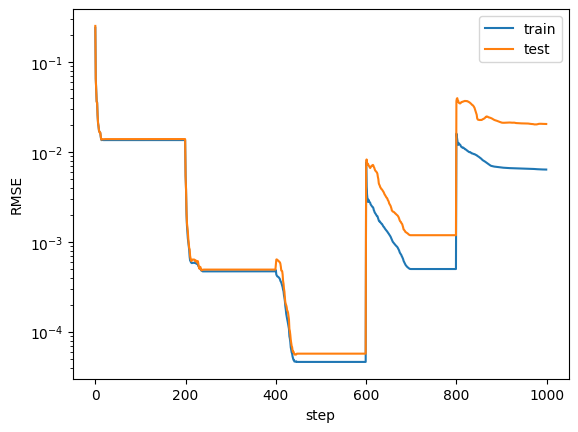

In [8]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.legend(['train', 'test'])
plt.ylabel('RMSE')
plt.xlabel('step')
plt.yscale('log')
# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/grid_chek1.png', bbox_inches='tight')

plt.show()


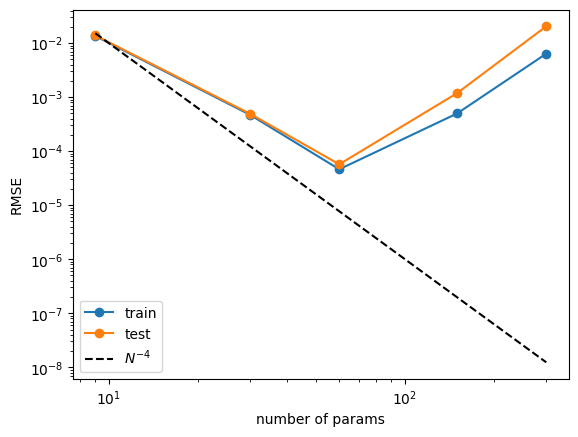

In [9]:
n_params = 3 * grids
train_vs_G = train_losses[(steps-1)::steps]
test_vs_G = test_losses[(steps-1)::steps]
plt.plot(n_params, train_vs_G, marker="o")
plt.plot(n_params, test_vs_G, marker="o")
plt.plot(n_params, 100*n_params**(-4.), ls="--", color="black")
plt.xscale('log')
plt.yscale('log')
plt.legend(['train', 'test', r'$N^{-4}$'])
plt.xlabel('number of params')
plt.ylabel('RMSE')

# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/grid_chek2.png', bbox_inches='tight')

plt.show()

In [13]:
# Здесь без refine обучаем модели без дообучения 
grids = np.array([3,10,20,50,100])


train_losses = []
test_losses = []
steps = 200
k = 3

for i in range(grids.shape[0]):
    
    model = KAN(width=[2,1,1], grid=grids[i], k=k, seed=1, device=device)

    results = model.fit(dataset, opt="LBFGS", steps=steps)
    train_losses += results['train_loss']
    test_losses += results['test_loss']

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.36e-02 | test_loss: 1.39e-02 | reg: 1.15e+01 | : 100%|█| 200/200 [00:07<00:00, 25.07


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.94e-01 | test_loss: 6.81e-01 | reg: 8.29e+00 | : 100%|█| 200/200 [00:32<00:00,  6.17


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.55e-01 | test_loss: 7.11e-01 | reg: 6.46e+00 | : 100%|█| 200/200 [00:42<00:00,  4.68


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.83e-01 | test_loss: 1.04e+00 | reg: 7.35e+00 | : 100%|█| 200/200 [00:45<00:00,  4.38

saving model version 0.1


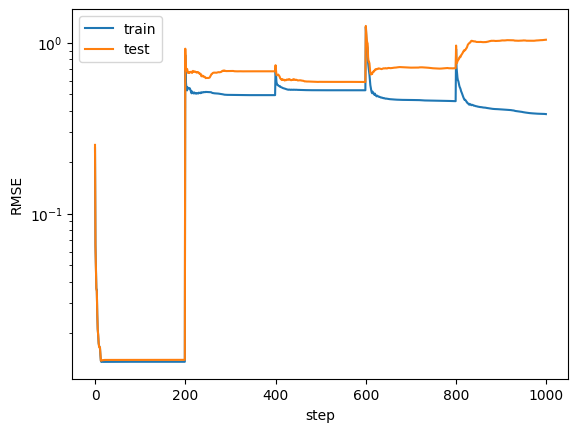

In [14]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.legend(['train', 'test'])
plt.ylabel('RMSE')
plt.xlabel('step')
plt.yscale('log')
# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/grid_chek3.png', bbox_inches='tight')

plt.show()


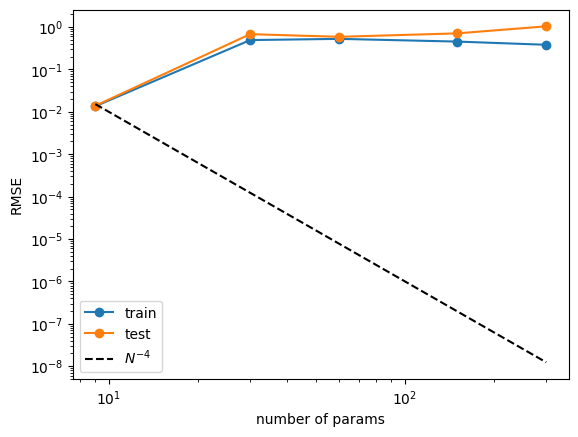

In [15]:
n_params = 3 * grids
train_vs_G = train_losses[(steps-1)::steps]
test_vs_G = test_losses[(steps-1)::steps]
plt.plot(n_params, train_vs_G, marker="o")
plt.plot(n_params, test_vs_G, marker="o")
plt.plot(n_params, 100*n_params**(-4.), ls="--", color="black")
plt.xscale('log')
plt.yscale('log')
plt.legend(['train', 'test', r'$N^{-4}$'])
plt.xlabel('number of params')
plt.ylabel('RMSE')

# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/grid_chek4.png', bbox_inches='tight')

plt.show()